# Projet : Système de recommandation d'images

## Présentation

Dans ce projet, vous allez construire un **Système de recommandation d'images** qui suggère des images aux utilisateurs en fonction de leurs préférences. Ce projet applique toutes les compétences que vous avez acquises lors des travaux pratiques : analyse de données, visualisation, clustering, classification et apprentissage automatique.

**Durée** : 3 séances de travaux pratiques
**Taille de l'équipe** : 2-3 étudiants
**Livrables** :
1. Un notebook Jupyter (`Nom1_Nom2_[Nom3].ipynb`)
2. Un rapport de synthèse de 4 pages (PDF)

---

## Objectifs d'apprentissage

En réalisant ce projet, vous allez :
- Automatiser la collecte de données à partir de sources web
- Extraire et traiter les métadonnées des images
- Appliquer des algorithmes de clustering pour analyser les caractéristiques des images
- Construire des profils de préférences utilisateurs
- Implémenter un algorithme de recommandation
- Visualiser efficacement les données
- Écrire des tests complets pour votre système

---

## Architecture du projet

Le système se compose de 7 tâches interconnectées :

```
┌─────────────────────────────────────────────────────────────────┐
│              SYSTÈME DE RECOMMANDATION D'IMAGES                 │
├─────────────────────────────────────────────────────────────────┤
│                                                                  │
│  ┌──────────────┐    ┌──────────────┐    ┌──────────────┐       │
│  │ 1. Collecte  │───▶│ 2. Étiquetage│───▶│ 3. Analyse   │       │
│  │ de données   │    │ & Annotation │    │ des données  │       │
│  └──────────────┘    └──────────────┘    └──────────────┘       │
│        │                    │                   │                │
│        ▼                    ▼                   ▼                │
│  ┌──────────────────────────────────────────────────────┐       │
│  │          Fichiers JSON (Stockage des métadonnées)     │       │
│  └──────────────────────────────────────────────────────┘       │
│        │                    │                   │                │
│        ▼                    ▼                   ▼                │
│  ┌──────────────┐    ┌──────────────┐    ┌──────────────┐       │
│  │ 4. Visuali-  │    │ 5. Système   │    │ 6. Tests     │       │
│  │ sation       │    │ de recomman- │    │              │       │
│  └──────────────┘    │ dation       │    └──────────────┘       │
│                      └──────────────┘                            │
│                             │                                    │
│                             ▼                                    │
│                    ┌──────────────┐                              │
│                    │ 7. Rapport   │                              │
│                    │ de synthèse  │                              │
│                    └──────────────┘                              │
└─────────────────────────────────────────────────────────────────┘
```

![Architecture](../../images/Project-Architecture.png "Architecture")

## Tâche 1 : Collecte de données

### Objectif
Collecter au moins **100 images sous licence libre** avec leurs métadonnées.

### Ce que vous devez faire

1. **Créer une structure de dossiers** :
   ```
   projet/
   ├── images/           # Images téléchargées
   ├── data/             # Fichiers JSON de métadonnées
   └── projet.ipynb      # Votre notebook
   ```

2. **Trouver des sources d'images** (choisissez une ou plusieurs) :
   - [Wikimedia Commons](https://commons.wikimedia.org/) - Utilisez des requêtes SPARQL (comme dans le TP 1)
   - [Unsplash API](https://unsplash.com/developers) - API gratuite pour des images de haute qualité
   - [Pexels API](https://www.pexels.com/api/) - Photos gratuites
   - [Flickr API](https://www.flickr.com/services/api/) - Images sous Creative Commons

3. **Télécharger les images programmatiquement** en utilisant les techniques du TP 1, Exercice 6

4. **Extraire et sauvegarder les métadonnées** pour chaque image :
   - Nom du fichier image
   - Dimensions de l'image (largeur, hauteur)
   - Format du fichier (.jpg, .png, etc.)
   - Taille du fichier (en Ko)
   - URL source
   - Informations de licence
   - Données EXIF (si disponibles) : modèle d'appareil photo, date de prise de vue, etc.

### Sortie attendue
- Dossier `images/` avec 100+ images
- `data/images_metadata.json` contenant les métadonnées de toutes les images

### Conseils
- Utilisez `PIL` pour obtenir les dimensions des images
- Utilisez `os.path.getsize()` pour obtenir la taille du fichier
- Utilisez l'extraction EXIF (voir TP 2, Exercice 2)
- Stockez les métadonnées sous forme de liste de dictionnaires au format JSON

---

In [3]:
import os
import requests
import json
from PIL import Image
from PIL.ExifTags import TAGS
import time

In [4]:
# --- CONFIGURATION ---
API_KEY = 'ldFcymw4sYP7Nj19T2QD0Ht7uucfsL6mg1QX4cquuDppagdhab8Ntx0u'
QUERY = 'castle' # Thème des images
NB_IMAGES_TOTAL = 100
IMAGES_DIR = 'images'
DATA_DIR = 'data'
JSON_PATH = os.path.join(DATA_DIR, 'images_metadata.json')

In [5]:
# 1. Création de la structure de dossiers
os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

headers = {"Authorization": API_KEY}
all_metadata = []
downloaded_count = 0
page = 1

print(f"Début de la collecte pour : {QUERY}")

while downloaded_count < NB_IMAGES_TOTAL:
    # Pexels limite à 80 images par page
    url = f"https://api.pexels.com/v1/search?query={QUERY}&per_page=80&page={page}"
    response = requests.get(url, headers=headers).json()

    if 'photos' not in response:
        print("Erreur API ou limite atteinte.")
        break

    for photo in response['photos']:
        if downloaded_count >= NB_IMAGES_TOTAL:
            break

        try:
            # Infos de base depuis l'API
            img_url = photo['src']['large'] # Version large pour avoir des métadonnées
            img_id = photo['id']
            ext = ".jpg" # Pexels fournit principalement du JPG
            filename = f"image_{img_id}{ext}"
            filepath = os.path.join(IMAGES_DIR, filename)

            # 2. Téléchargement de l'image
            img_data = requests.get(img_url).content
            with open(filepath, 'wb') as f:
                f.write(img_data)

            # 3. Extraction des métadonnées avec PIL
            with Image.open(filepath) as img:
                width, height = img.size
                img_format = img.format

                # Extraction EXIF (pas très utile car pexel enlève l'exif mais demandé ds le projet)
                exif_data = {}
                info = img._getexif()
                if info:
                    for tag, value in info.items():
                        decoded = TAGS.get(tag, tag)
                        # On filtre pour ne garder que des types de données sérialisables en JSON
                        if isinstance(value, (str, int, float)):
                            exif_data[decoded] = value

            # 4. Compilation des métadonnées
            metadata = {
                "nom_fichier": filename,
                "dimensions": {"largeur": width, "hauteur": height},
                "format": img_format,
                "taille_ko": round(os.path.getsize(filepath) / 1024, 2),
                "url_source": photo['url'],
                "photographe": photo['photographer'],
                "licence": "Pexels License",
                "exif": exif_data
            }

            all_metadata.append(metadata)
            downloaded_count += 1
            if downloaded_count % 10 == 0:
                print(f"{downloaded_count}/{NB_IMAGES_TOTAL} images traitées...")

        except Exception as e:
            print(f"Erreur sur l'image {img_id}: {e}")

    page += 1
    time.sleep(1) # Pause pour pas tuer l'API

# 5. Sauvegarde en JSON
with open(JSON_PATH, 'w', encoding='utf-8') as f:
    json.dump(all_metadata, f, indent=4, ensure_ascii=False)

print(f"\nTerminé ! {downloaded_count} images et métadonnées sauvegardées dans : {JSON_PATH}")

Début de la collecte pour : castle
10/100 images traitées...
20/100 images traitées...
30/100 images traitées...
40/100 images traitées...
50/100 images traitées...
60/100 images traitées...
70/100 images traitées...
80/100 images traitées...
90/100 images traitées...
100/100 images traitées...

Terminé ! 100 images et métadonnées sauvegardées dans : data/images_metadata.json


## Tâche 2 : Étiquetage et annotation

### Objectif
Ajouter des étiquettes descriptives et des caractéristiques calculées à chaque image.

### Ce que vous devez faire

1. **Extraire les informations de couleur** en utilisant le clustering KMeans (TP 2, Exercice 3) :
   - Trouver les 3-5 couleurs prédominantes dans chaque image
   - Stocker les couleurs sous forme de valeurs RGB et/ou de noms de couleurs

2. **Déterminer l'orientation de l'image** :
   - Paysage (largeur > hauteur)
   - Portrait (hauteur > largeur)
   - Carré (largeur ≈ hauteur)

3. **Ajouter des tags de catégorie** (choisissez une approche) :
   - **Manuelle** : Créer une interface simple pour taguer les images
   - **Automatisée** : Utiliser les catégories/tags de la source d'images
   - **Hybride** : Commencer avec les tags sources, permettre un affinage par l'utilisateur

4. **Classifier la taille de l'image** :
   - Vignette : < 500px
   - Moyenne : 500-1500px
   - Grande : > 1500px

### Sortie attendue
- `data/images_labels.json` avec métadonnées enrichies :
```json
{
  "image_001.jpg": {
    "predominant_colors": [[255, 128, 0], [0, 100, 200], [50, 50, 50]],
    "color_names": ["orange", "bleu", "gris"],
    "orientation": "paysage",
    "size_category": "moyenne",
    "tags": ["nature", "coucher de soleil", "plage"]
  }
}
```

### Conseils
- Réutilisez votre code d'extraction de couleurs KMeans du TP 2
- Pensez à utiliser un mapping de noms de couleurs (RGB → nom de couleur)
- Stockez toutes les annotations dans un fichier JSON structuré

---

In [6]:
import os
import json
import numpy as np
from PIL import Image
from sklearn.cluster import KMeans

In [7]:
# --- CONFIGURATION ---
METADATA_PATH = 'data/images_metadata.json'
OUTPUT_LABELS_PATH = 'data/images_labels.json'
IMAGES_DIR = 'images'

In [8]:
def nommer_couleur(rgb):
    """Associe un nom simple à une valeur RGB par distance euclidienne."""
    r, g, b = rgb
    couleurs_basiques = {
        "rouge": (255, 0, 0), "vert": (0, 255, 0), "bleu": (0, 0, 255),
        "jaune": (255, 255, 0), "cyan": (0, 255, 255), "magenta": (255, 0, 255),
        "blanc": (255, 255, 255), "noir": (0, 0, 0), "gris": (128, 128, 128),
        "orange": (255, 165, 0), "marron": (165, 42, 42)
    }
    nom_proche = min(couleurs_basiques.keys(),
                     key=lambda c: sum((s - q) ** 2 for s, q in zip(rgb, couleurs_basiques[c])))
    return nom_proche

In [9]:
def annoter_image(chemin_image, n_couleurs=3):
    """Analyse une image pour extraire couleurs, orientation et catégorie de taille."""
    with Image.open(chemin_image).convert('RGB') as img:
        w, h = img.size

        # 1. Déterminer l'orientation
        if w > h: orientation = "paysage"
        elif h > w: orientation = "portrait"
        else: orientation = "carré"

        # 2. Classifier la taille
        max_dim = max(w, h)
        if max_dim < 500: size_cat = "vignette"
        elif max_dim <= 1500: size_cat = "moyenne"
        else: size_cat = "grande"

        # 3. Extraire les couleurs (Utilisation de getdata / get_flattened_data)
        # On redimensionne pour que le KMeans ne soit pas trop lent
        img_temp = img.resize((100, 100))

        # On utilise la méthode gte_flattened_data() (ou getdata en cas d'erreur)
        try:
            raw_data = img_temp.get_flattened_data()
        except AttributeError:
            raw_data = img_temp.getdata()

        pixels = np.array(raw_data).reshape(-1, 3)

        kmeans = KMeans(n_clusters=n_couleurs, n_init=10, random_state=42)
        kmeans.fit(pixels)

        couleurs_rgb = kmeans.cluster_centers_.astype(int).tolist()
        noms_couleurs = [nommer_couleur(tuple(c)) for c in couleurs_rgb]

        return {
            "predominant_colors": couleurs_rgb,
            "color_names": noms_couleurs,
            "orientation": orientation,
            "size_category": size_cat
        }

In [10]:
# --- TRAITEMENT GLOBAL ---
if os.path.exists(METADATA_PATH):
    with open(METADATA_PATH, 'r', encoding='utf-8') as f:
        metadata_list = json.load(f)

    labels_final = {}

    print(f"Annotation de {len(metadata_list)} images en cours...")

    for item in metadata_list:
        nom_fich = item['nom_fichier']
        chemin = os.path.join(IMAGES_DIR, nom_fich)

        if os.path.exists(chemin):
            try:
                # Analyse technique
                annotations = annoter_image(chemin)

                # Ajout des tags (approche automatisée à partir de la source)
                # On récupère les mots-clés dans l'URL ou on utilise le nom du photographe
                tags = ["photo", annotations["orientation"]]
                if 'photographer' in item:
                    tags.append(item['photographer'].lower())

                annotations["tags"] = tags

                # On remplit le dictionnaire final avec le nom du fichier comme clé
                labels_final[nom_fich] = annotations

            except Exception as e:
                print(f"Erreur sur {nom_fich}: {e}")

    # Sauvegarde du fichier JSON final
    with open(OUTPUT_LABELS_PATH, 'w', encoding='utf-8') as f:
        json.dump(labels_final, f, indent=4, ensure_ascii=False)

    print(f"Terminé ! Fichier sauvegardé sous : {OUTPUT_LABELS_PATH}")
else:
    print("Erreur : Le fichier 'images_metadata.json' est introuvable.")

Annotation de 100 images en cours...
Terminé ! Fichier sauvegardé sous : data/images_labels.json


## Tâche 3 : Analyse des données

### Objectif
Construire des profils de préférences utilisateurs basés sur leurs sélections d'images.

### Ce que vous devez faire

1. **Simuler des utilisateurs** (créez au moins 5 utilisateurs) :
   - Chaque utilisateur "favorite" 10-20 images
   - Les utilisateurs doivent avoir des préférences différentes (un aime la nature, un autre l'architecture, etc.)

2. **Construire des profils utilisateurs** en analysant leurs images favorites :
   ```python
   user_profile = {
       "user_id": "utilisateur_001",
       "favorite_colors": ["bleu", "vert"],       # Couleurs les plus fréquentes
       "favorite_orientation": "paysage",          # Orientation la plus fréquente
       "favorite_size": "moyenne",                 # Taille la plus fréquente
       "favorite_tags": ["nature", "eau"],         # Tags les plus fréquents
       "favorite_images": ["img_01.jpg", ...]      # Liste des images favorites
   }
   ```

3. **Analyser les tendances** entre les utilisateurs :
   - Quelles couleurs sont les plus populaires globalement ?
   - Quels tags apparaissent le plus fréquemment ?
   - Y a-t-il des clusters d'utilisateurs avec des préférences similaires ?

### Sortie attendue
- `data/users.json` avec les profils utilisateurs
- Résultats d'analyse montrant les tendances de préférences utilisateurs

### Conseils
- Utilisez pandas pour l'analyse de données (groupby, value_counts)
- Utilisez Counter de collections pour trouver les éléments les plus fréquents
- Envisagez d'utiliser le clustering pour grouper les utilisateurs similaires

---

# 3.1- Création des utilisateurs

In [11]:
import json
import random
import pandas as pd
from collections import Counter
import os

In [12]:
# Chemins
LABELS_PATH = 'data/images_labels.json'
USERS_JSON_PATH = 'data/users.json'

# Chargement des données de la Tâche 2
with open(LABELS_PATH, 'r', encoding='utf-8') as f:
    images_data = json.load(f)

image_names = list(images_data.keys())

# Simulation de 5 utilisateurs avec des profils typés
user_seeds = {
    "fan_nature": ["vert", "paysage"],
    "archi_lover": ["gris", "grande"],
    "minimaliste": ["blanc", "carré", "noir"],
    "color_addict": ["orange", "bleu", "jaune"],
    "street_photog": ["portrait", "moyenne"]
}

users_favorites = {}

for user_id, preferences in user_seeds.items():
    # On sélectionne 15 images qui matchent un peu avec les préférences (ou au hasard)
    # Pour simplifier ici, on prend 15 images aléatoires par utilisateur
    users_favorites[user_id] = random.sample(image_names, 15)

# 3.2- Contruction des profils

In [13]:
def construire_profil(user_id, favorites, images_db):
    # Listes pour stocker les attributs des images likées
    colors, orientations, sizes, tags = [], [], [], []

    for img_name in favorites:
        data = images_db[img_name]
        colors.extend(data['color_names'])
        orientations.append(data['orientation'])
        sizes.append(data['size_category'])
        tags.extend(data['tags'])

    # Trouver les plus fréquents avec Counter
    def top_elements(liste, n=2):
        return [item for item, count in Counter(liste).most_common(n)]

    return {
        "user_id": user_id,
        "favorite_colors": top_elements(colors, 3),
        "favorite_orientation": Counter(orientations).most_common(1)[0][0],
        "favorite_size": Counter(sizes).most_common(1)[0][0],
        "favorite_tags": top_elements(tags, 5),
        "favorite_images": favorites
    }

# Génération de tous les profils
all_user_profiles = [construire_profil(uid, favs, images_data) for uid, favs in users_favorites.items()]

# Sauvegarde
with open(USERS_JSON_PATH, 'w', encoding='utf-8') as f:
    json.dump(all_user_profiles, f, indent=4, ensure_ascii=False)

# 3.3- Analyse des préférences

In [14]:
# Conversion en DataFrame pour l'analyse
df_users = pd.DataFrame(all_user_profiles)

print("--- ANALYSE DES TENDANCES GLOBALES ---")

# 1. Couleurs les plus populaires
all_colors = [color for sublist in df_users['favorite_colors'] for color in sublist]
print("\nTop Couleurs chez les utilisateurs :")
print(pd.Series(all_colors).value_counts().head(3))

# 2. Tags les plus fréquents
all_tags = [tag for sublist in df_users['favorite_tags'] for tag in sublist]
print("\nTop Tags globaux :")
print(pd.Series(all_tags).value_counts().head(5))

# 3. Orientations préférées
print("\nRépartition des orientations favorites :")
print(df_users['favorite_orientation'].value_counts())

--- ANALYSE DES TENDANCES GLOBALES ---

Top Couleurs chez les utilisateurs :
gris     5
blanc    5
noir     4
Name: count, dtype: int64

Top Tags globaux :
photo       5
paysage     5
portrait    5
Name: count, dtype: int64

Répartition des orientations favorites :
favorite_orientation
paysage     3
portrait    2
Name: count, dtype: int64


# 3.4- Bonus : clustering des utilisateurs par préférences

In [15]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans

In [16]:
# On crée une "phrase" de préférences pour chaque utilisateur
df_users['features'] = df_users['favorite_colors'].apply(lambda x: " ".join(x)) + " " + \
                       df_users['favorite_tags'].apply(lambda x: " ".join(x))

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df_users['features'])

# On groupe en 2 clusters (par exemple)
model = KMeans(n_clusters=2, random_state=42, n_init=10)
df_users['cluster'] = model.fit_predict(X)

print("\nGroupes d'utilisateurs similaires :")
print(df_users[['user_id', 'cluster']])


Groupes d'utilisateurs similaires :
         user_id  cluster
0     fan_nature        0
1    archi_lover        0
2    minimaliste        0
3   color_addict        0
4  street_photog        1


## Tâche 4 : Visualisation des données

### Objectif
Créer des visualisations qui révèlent des informations sur votre collection d'images et les préférences des utilisateurs.

### Visualisations requises

1. **Statistiques de la collection d'images** :
   - Diagramme en barres : Nombre d'images par orientation
   - Diagramme en barres : Nombre d'images par catégorie de taille
   - Diagramme circulaire : Distribution des formats d'images

2. **Analyse des couleurs** :
   - Afficher les couleurs prédominantes sous forme de palettes de couleurs
   - Histogramme des fréquences de couleurs sur toutes les images

3. **Préférences utilisateurs** :
   - Diagramme en barres : Couleurs favorites par utilisateur
   - Graphique de comparaison : Préférences des utilisateurs côte à côte

4. **Analyse des tags** :
   - Diagramme en barres : Tags les plus fréquents
   - Nuage de mots (optionnel) : Visualisation de la fréquence des tags

### Sortie attendue
- Au moins 6 visualisations différentes dans votre notebook
- Tous les graphiques doivent avoir des titres, des légendes et des axes étiquetés

### Conseils
- Utilisez matplotlib pour toutes les visualisations (TP 2, Exercice 1)
- Sauvegardez les graphiques importants avec `plt.savefig()`
- Utilisez les subplots pour grouper les visualisations liées

---

# 4.1- Préparation des données

In [17]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
try:
    from wordcloud import WordCloud
except ImportError:
    WordCloud = None

In [18]:
# Chargement
with open('data/images_metadata.json', 'r', encoding= 'utf-8') as f: meta_data = json.load(f)
with open('data/images_labels.json', 'r') as f: labels_data = json.load(f)
with open('data/users.json', 'r') as f: users_data = json.load(f)

# Création des DataFrames
df_meta = pd.DataFrame(meta_data)
df_labels = pd.DataFrame.from_dict(labels_data, orient='index')
df_users = pd.DataFrame(users_data)

# 4.2- Statistique de la collection ( 3 graphiques)

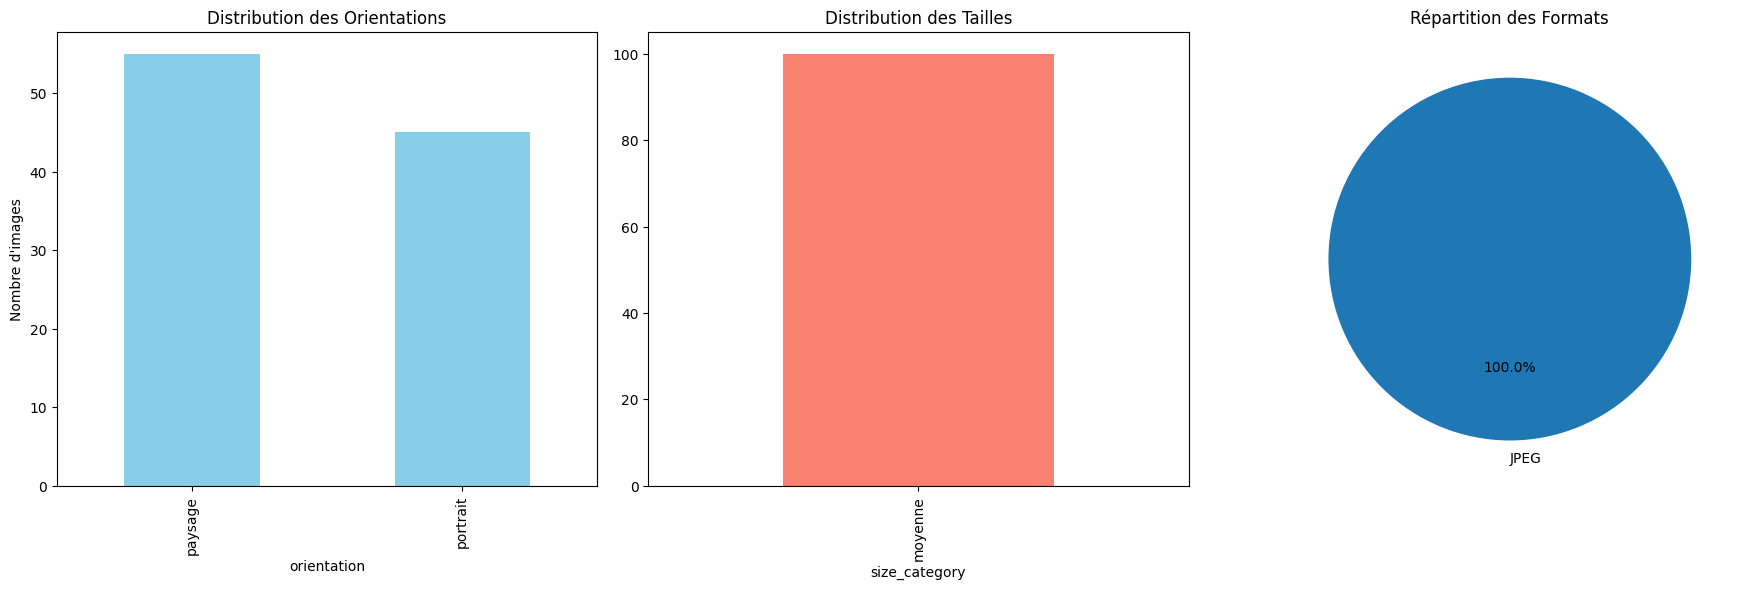

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# A. Orientation
df_labels['orientation'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title("Distribution des Orientations")
axes[0].set_ylabel("Nombre d'images")

# B. Catégorie de taille
df_labels['size_category'].value_counts().plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title("Distribution des Tailles")

# C. Formats (Pie chart)
df_meta['format'].value_counts().plot(kind='pie', ax=axes[2], autopct='%1.1f%%', startangle=90)
axes[2].set_title("Répartition des Formats")

plt.tight_layout()
plt.savefig('stats_collection.png')
plt.show()

# 4.3- Analyse des couleurs

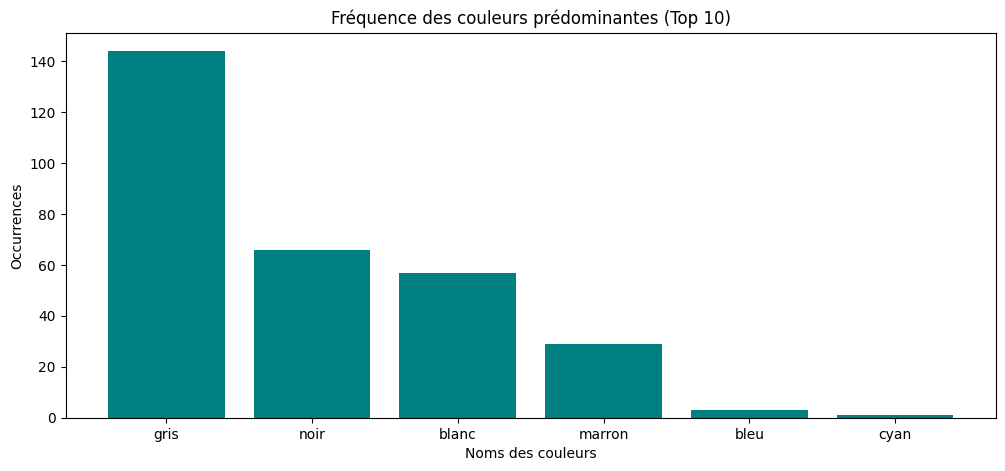

In [20]:
plt.figure(figsize=(12, 5))

# Calcul des fréquences de noms de couleurs
toutes_couleurs = [c for liste in df_labels['color_names'] for c in liste]
compte_couleurs = Counter(toutes_couleurs)

# Histogramme
noms, counts = zip(*compte_couleurs.most_common(10))
plt.bar(noms, counts, color='teal')
plt.title("Fréquence des couleurs prédominantes (Top 10)")
plt.xlabel("Noms des couleurs")
plt.ylabel("Occurrences")

plt.savefig('frequence_couleurs.png')
plt.show()

# 4.4- Préférences utilisateurs

<Figure size 1400x600 with 0 Axes>

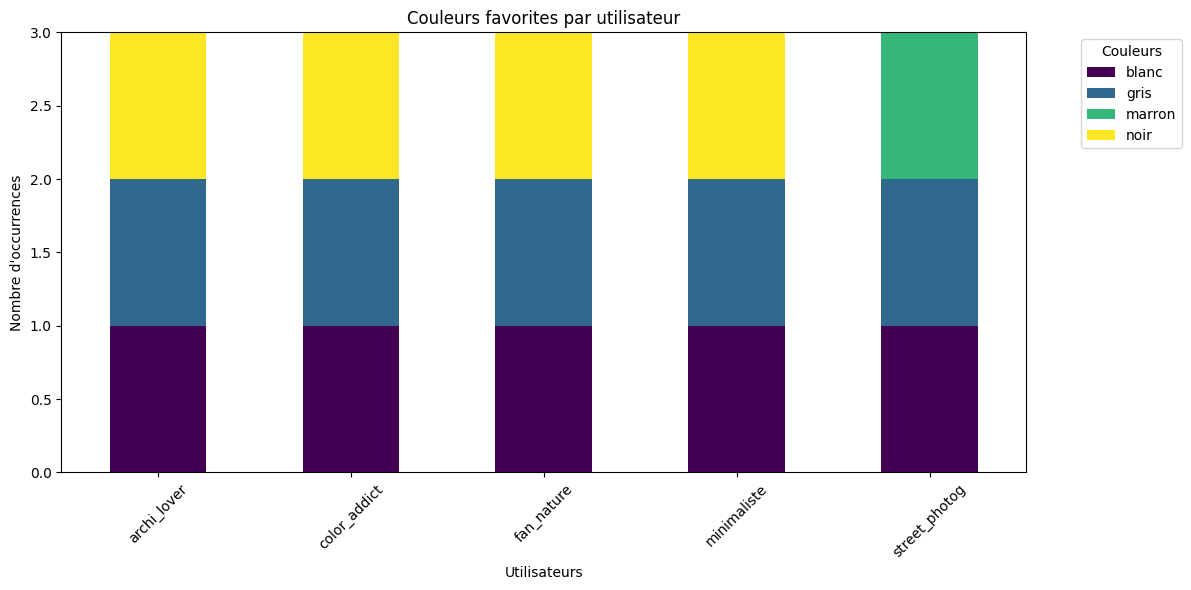

/tmp/ipykernel_2886/3337398056.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


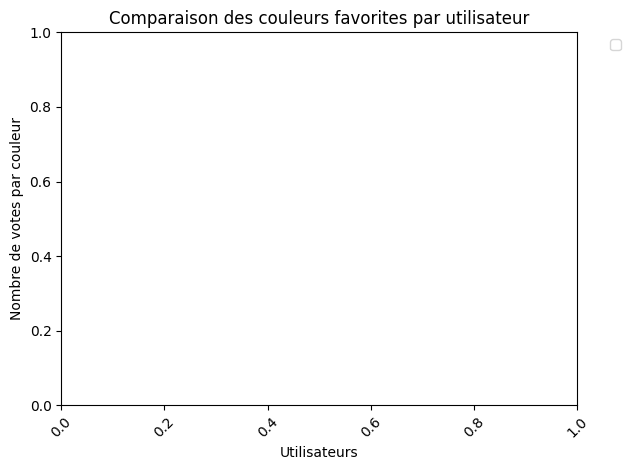

In [26]:
# Préparation des données pour le graphique
user_color_prefs = df_users.explode('favorite_colors')

plt.figure(figsize=(14, 6))
# On croise l'ID utilisateur et ses couleurs favorites

# 1. On explose la liste ET on réinitialise l'index pour éviter les doublons
df_clean = df_users.explode('favorite_colors').reset_index(drop=True)

# 2. On crée la table de comptage avec un pivot_table ou groupby (plus stable que crosstab ici)
# Cela compte combien de fois chaque utilisateur a chaque couleur
color_counts = df_clean.groupby(['user_id', 'favorite_colors']).size().unstack(fill_value=0)

# 3. On affiche le graphique
color_counts.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')

plt.title("Couleurs favorites par utilisateur")
plt.xlabel("Utilisateurs")
plt.ylabel("Nombre d'occurrences")
plt.legend(title="Couleurs", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.title("Comparaison des couleurs favorites par utilisateur")
plt.xlabel("Utilisateurs")
plt.ylabel("Nombre de votes par couleur")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('preferences_utilisateurs.png')
plt.show()

# 4.5- Analyse des Tags (Barres + Nuage de mots)

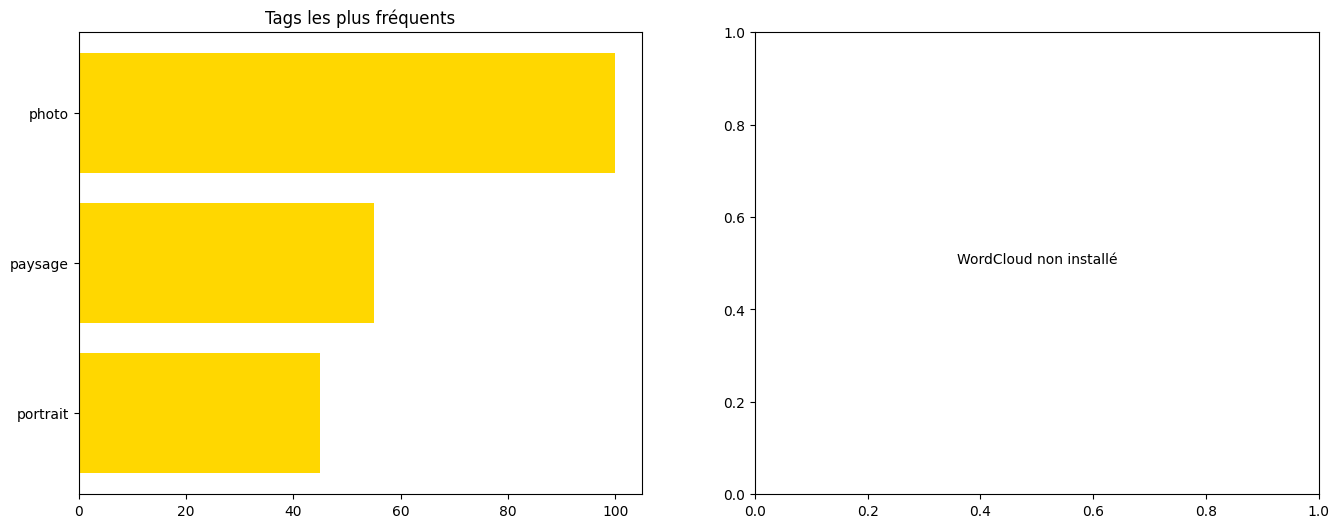

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# A. Top Tags (Barres)
tous_tags = [t for liste in df_labels['tags'] for t in liste]
top_tags = Counter(tous_tags).most_common(10)
tags_noms, tags_counts = zip(*top_tags)

axes[0].barh(tags_noms, tags_counts, color='gold')
axes[0].invert_yaxis() # Le plus gros en haut
axes[0].set_title("Tags les plus fréquents")

# B. Nuage de mots (Optionnel)
if WordCloud:
    wc = WordCloud(width=800, height=400, background_color='white').generate(" ".join(tous_tags))
    axes[1].imshow(wc, interpolation='bilinear')
    axes[1].axis('off')
    axes[1].set_title("Nuage de mots des Tags")
else:
    axes[1].text(0.5, 0.5, "WordCloud non installé", ha='center')

plt.savefig('analyse_tags.png')
plt.show()

## Tâche 5 : Système de recommandation

### Objectif
Implémenter un système qui recommande des images aux utilisateurs en fonction de leurs préférences.

### Choisissez votre approche

Vous devez implémenter **au moins une** de ces approches :

#### Option A : Filtrage basé sur le contenu (utilisant la classification)
Recommander des images similaires à ce que l'utilisateur a déjà aimé.

```python
# Entraîner un classificateur sur les favoris de l'utilisateur
# Caractéristiques : couleur, orientation, taille, tags
# Étiquette : Favori / Non favori
# Prédire quelles images non vues l'utilisateur aimerait
```

**Utiliser** : Decision Tree, Random Forest, ou SVM (TP 3, Exercices 2-3)

#### Option B : Recommandation basée sur le clustering
Grouper les images similaires ensemble et recommander depuis le même cluster.

```python
# Clusterer toutes les images basées sur les caractéristiques
# Trouver à quel cluster appartiennent les favoris de l'utilisateur
# Recommander d'autres images du même cluster
```

**Utiliser** : KMeans (TP 2, Exercices 3-5)

#### Option C : Approche hybride
Combiner les deux méthodes pour de meilleures recommandations.

### Exigences d'implémentation

1. **Entrée** : ID utilisateur
2. **Sortie** : Liste de 5-10 images recommandées (pas déjà favorites)
3. **Explication** : Brève raison pour laquelle chaque image est recommandée

### Sortie attendue
```python
def recommend_images(user_id, n_recommendations=5):
    """
    Recommander des images pour un utilisateur.

    Args:
        user_id: L'utilisateur pour lequel recommander
        n_recommendations: Nombre d'images à recommander

    Returns:
        Liste de tuples (nom_fichier_image, raison)
    """
    # Votre implémentation
    pass
```

### Conseils
- Commencez avec les exemples dans `examples/recommendation.ipynb`
- Utilisez LabelEncoder pour convertir les caractéristiques catégorielles en nombres
- Testez vos recommandations manuellement - ont-elles du sens ?

---

# 5.1- Préparation des données (Preprocessing) (on choisit d'implémenter l'option 1)

In [23]:
import pandas as pd
import json
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

In [24]:
# 1. Chargement des données
with open('data/images_labels.json', 'r') as f:
    labels_db = json.load(f)
with open('data/users.json', 'r') as f:
    users_list = json.load(f)

# 2. Création d'un DataFrame de caractéristiques pour TOUTES les images
features_list = []
for name, info in labels_db.items():
    features_list.append({
        "name": name,
        "orientation": info["orientation"],
        "size": info["size_category"],
        "primary_color": info["color_names"][0] # On prend la couleur principale
    })

df_features = pd.DataFrame(features_list)

# 3. Encodage des catégories en nombres
le_orient = LabelEncoder()
le_size = LabelEncoder()
le_color = LabelEncoder()

df_features['orient_enc'] = le_orient.fit_transform(df_features['orientation'])
df_features['size_enc'] = le_size.fit_transform(df_features['size'])
df_features['color_enc'] = le_color.fit_transform(df_features['primary_color'])

X_all = df_features[['orient_enc', 'size_enc', 'color_enc']]

# 5.2- Implémentation du système de recommandation

In [25]:
def recommend_images(user_id, n_recommendations=5):
    # Trouver les données de l'utilisateur
    user = next((u for u in users_list if u['user_id'] == user_id), None)
    if not user:
        return "Utilisateur introuvable."

    favorites = user['favorite_images']

    # Préparation des étiquettes (Y) pour cet utilisateur
    # 1 = Aimé (favoris), 0 = Inconnu (on échantillonne des images non-favorites)
    df_features['target'] = df_features['name'].apply(lambda x: 1 if x in favorites else 0)

    # On crée un dataset d'entraînement équilibré
    positives = df_features[df_features['target'] == 1]
    negatives = df_features[df_features['target'] == 0].sample(len(positives) * 2, random_state=42)
    train_df = pd.concat([positives, negatives])

    # Entraînement du Random Forest
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(train_df[['orient_enc', 'size_enc', 'color_enc']], train_df['target'])

    # Prédiction sur les images que l'utilisateur n'a pas encore "likées"
    unseen_images = df_features[df_features['target'] == 0].copy()
    unseen_images['score'] = model.predict_proba(unseen_images[['orient_enc', 'size_enc', 'color_enc']])[:, 1]

    # Tri par score le plus élevé
    recommendations = unseen_images.sort_values(by='score', ascending=False).head(n_recommendations)

    results = []
    for _, row in recommendations.iterrows():
        # Génération d'une raison basée sur les caractéristiques
        raison = f"Cette image correspond à votre goût pour le format {row['orientation']} et la couleur {row['primary_color']}."
        results.append((row['name'], raison))

    return results

# --- TEST ---
print(f"Recommandations pour 'archi_lover' :")
for img, reason in recommend_images("archi_lover"):
    print(f"-> {img} : {reason}")

Recommandations pour 'archi_lover' :
-> image_7962980.jpg : Cette image correspond à votre goût pour le format portrait et la couleur gris.
-> image_36377089.jpg : Cette image correspond à votre goût pour le format portrait et la couleur gris.
-> image_36331383.jpg : Cette image correspond à votre goût pour le format portrait et la couleur gris.
-> image_36368543.jpg : Cette image correspond à votre goût pour le format portrait et la couleur gris.
-> image_19487462.jpg : Cette image correspond à votre goût pour le format portrait et la couleur gris.


## Tâche 6 : Tests

### Objectif
Vérifier que votre système fonctionne correctement.

### Tests requis

1. **Tests de validation des données** :
   - Toutes les images existent dans le dossier images
   - Toutes les images ont des métadonnées
   - Les valeurs des métadonnées sont valides (pas de dimensions négatives, etc.)

2. **Tests des fonctions** :
   - L'extraction de couleurs retourne des valeurs RGB valides
   - La génération de profil utilisateur fonctionne correctement
   - La fonction de recommandation retourne le nombre de résultats attendu

3. **Tests de qualité des recommandations** :
   - Les images recommandées ne sont pas déjà dans les favoris de l'utilisateur
   - Les recommandations correspondent aux préférences de l'utilisateur (ex. si l'utilisateur aime les images bleues, les recommandations devraient inclure des images bleues)

### Sortie attendue
```python
def test_data_integrity():
    """Tester que toutes les données sont valides"""
    # Vos tests
    assert len(images) >= 100, "Besoin d'au moins 100 images"
    assert all_images_have_metadata(), "Métadonnées manquantes"

def test_recommendation_system():
    """Tester que les recommandations fonctionnent"""
    recommendations = recommend_images("utilisateur_001", 5)
    assert len(recommendations) == 5, "Devrait retourner 5 recommandations"
    # Plus de tests...
```

### Conseils
- Utilisez les instructions `assert` pour des tests simples
- Affichez des messages clairs de succès/échec
- Testez les cas limites (profil utilisateur vide, nouvel utilisateur, etc.)

---

In [39]:
import os

def test_data_integrity():
    print("Test des données")
    
    # Vérifier qu'on a au moins 100 images
    assert len(labels_db) >= 100, "Moins de 100 images annotées"

    #Vérifier que chaque image existe
    for img_name in labels_db.keys():
        path = os.path.join(IMAGES_DIR, img_name)
        assert os.path.exists(path), f"Image manquante : {img_name}"

    #Vérifier que chaque image a des métadonnées valides
    for img_name, data in labels_db.items():
        # orientation existe
        assert "orientation" in data, f"Orientation manquante pour {img_name}"

        #size_category existe
        assert "size_category" in data, f"Taille manquante pour {img_name}"

        # ouleurs RGB valides
        for rgb in data["predominant_colors"]:
            assert len(rgb) == 3, "RGB invalide"
            assert all(0 <= val <= 255 for val in rgb), "Valeur RGB hors limite"

    print("Toutes les données sont valides")

In [42]:
def test_recommendation_system():
    print("Test du système de recommandation")
    
    for user in users_list:
        recs = recommend_images(user["user_id"], 5)

        #Vérifier nombre de recommandations
        assert len(recs) == 5, "Le système doit retourner 5 recommandations"

        favorites = user["favorite_images"]

        for img_name, _ in recs:
            #Vérifier que ce n'est pas déjà un favori
            assert img_name not in favorites, "Image déjà dans les favoris de l'utilisateur"

        # Vérifier que la recommandation correspond aux préférences
        preferred_colors = user["favorite_colors"]

        #On vérifie qu'au moins chaque recommendation contient une couleur aimée
        match_found = False

        for img_name, _ in recs:
            image_color = df_features[df_features["name"] == img_name]["primary_color"].values[0]
            if image_color in preferred_colors:
                match_found = True

        assert match_found, "Les recommandations ne correspondent pas aux préférences"

    print("Le système de recommandation fonctionne correctement.")

In [43]:
test_data_integrity()
test_recommendation_system()

print("Tous les tests sont passés avec succès.")

Test des données
Toutes les données sont valides
Test du système de recommandation
Le système de recommandation fonctionne correctement.
Tous les tests sont passés avec succès.


## Tâche 7 : Rapport de synthèse

### Objectif
Écrire un rapport de 5 pages résumant votre projet.

### Sections requises

1. **Introduction** (0,5 page)
   - Objectif du projet
   - Votre approche en bref

2. **Collecte de données** (0,5 page)
   - Sources d'images et licences
   - Nombre d'images collectées
   - Métadonnées stockées

3. **Méthodologie** (2,5 page)
   - Approche d'étiquetage (comment vous avez extrait les caractéristiques)
   - Construction du profil utilisateur
   - Algorithme de recommandation choisi et pourquoi
   - Inclure le diagramme d'architecture

4. **Résultats** (1 page)
   - Visualisations clés (2-3 figures)
   - Précision/qualité des recommandations
   - Découvertes intéressantes

5. **Limitations et travaux futurs** (0,25 page)
   - Qu'est-ce qui n'a pas bien fonctionné ?
   - Comment pourrait-on l'améliorer ?

6. **Conclusion** (0,25 page)
   - Résumé des réalisations
   - Auto-évaluation

### Format
- 5 pages maximum
- Format PDF
- Pas de code dans le rapport (seulement les résultats et explications)
- Inclure les références/bibliographie

---

## Critères d'évaluation

| Tâche | Points | Critères clés |
|-------|--------|---------------|
| Collecte de données | 15% | Automatisation, 100+ images, métadonnées complètes |
| Étiquetage & Annotation | 15% | Extraction de couleurs, catégorisation appropriée |
| Analyse des données | 15% | Profils utilisateurs, analyse des préférences |
| Visualisation des données | 15% | 6+ visualisations, formatage correct |
| Système de recommandation | 20% | Algorithme fonctionnel, recommandations raisonnables |
| Tests | 10% | Tests complets, tous passent |
| Rapport de synthèse | 10% | Clair, complet, bien structuré |

---


## Soumission

### Fichiers à soumettre
```
Nom1_Nom2_[Nom3].zip
├── Nom1_Nom2_[Nom3].ipynb    # Votre notebook
├── data/
│   ├── images_metadata.json
│   ├── images_labels.json
│   └── users.json
└── rapport_synthese.pdf
```

### Notes importantes
- **NE SOUMETTEZ PAS** le dossier images (trop volumineux)
- Assurez-vous que votre notebook s'exécute sans erreurs
- Incluez des commentaires expliquant votre code
- Renommez les fichiers avec les noms des membres de votre équipe

---

## Pour commencer

1. Commencez avec le notebook template : `fr/Projet/projet.ipynb`
2. Consultez les exemples dans `examples/recommendation.ipynb`
3. Réutilisez le code de vos travaux pratiques
4. Travaillez progressivement - complétez chaque tâche avant de passer à la suivante

**Bon courage !**